In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Load data and basic stats

In [5]:
df = pd.read_csv("C:\\Users\\harsh\\Downloads\\train.csv")

In [9]:
df.shape

(891, 12)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [15]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Visualization

In [16]:
def fun1(value):
    if (value == "male"):
        return 1
    else:
        return 0

In [17]:
def fun2(value):
    if (value == 'S'):
        return 0
    elif (value == 'C'):
        return 1
    elif (value == 'Q'):
        return 2
    else:
        return 0

In [18]:
df["Sex"] = df["Sex"].apply(fun1)

In [19]:
df["Embarked"] = df["Embarked"].apply(fun2)

In [20]:
df = df.drop("Cabin", axis=1)

In [21]:
df.shape

(891, 11)

In [33]:
px.box(df["Sex"], df["Age"], color=df["Survived"])

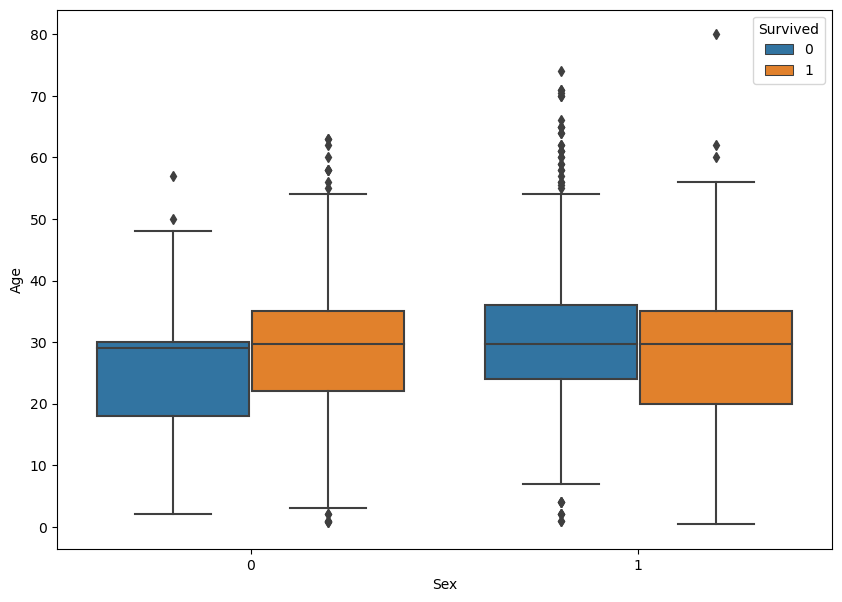

In [38]:
plt.figure(figsize=(10,7))
box = sns.boxplot(df["Sex"], df["Age"], hue=df["Survived"])
plt.show()

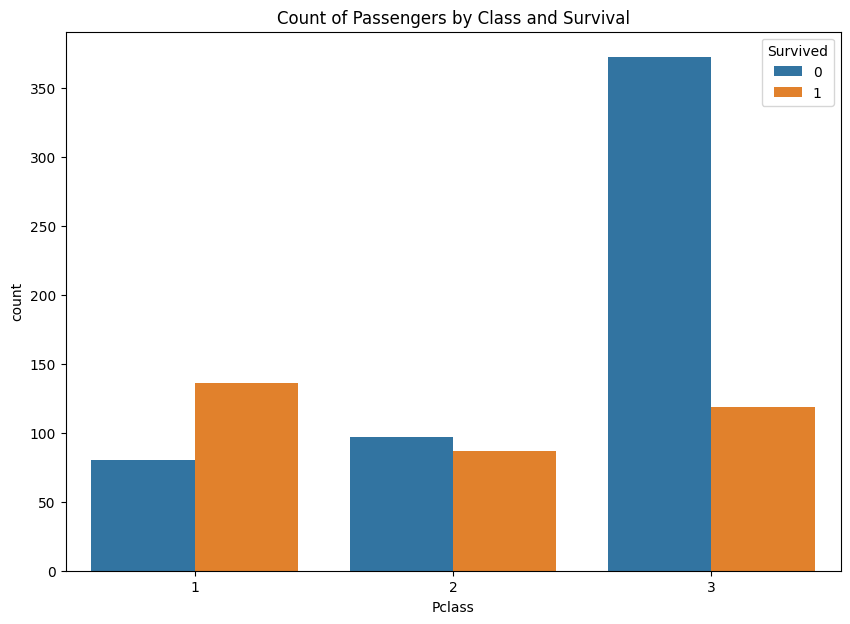

In [10]:
plt.figure(figsize=(10, 7))
sns.countplot(x='Pclass', data=df, hue='Survived')
plt.title('Count of Passengers by Class and Survival')
plt.show()

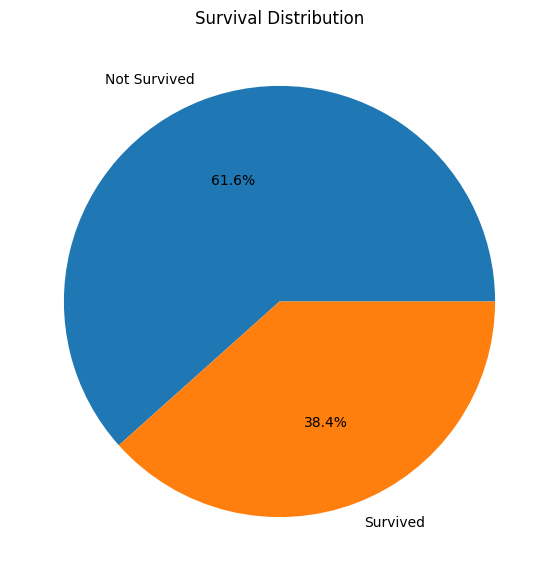

In [11]:
plt.figure(figsize=(10, 7))
df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Not Survived', 'Survived'])
plt.title('Survival Distribution')
plt.ylabel('')
plt.show()

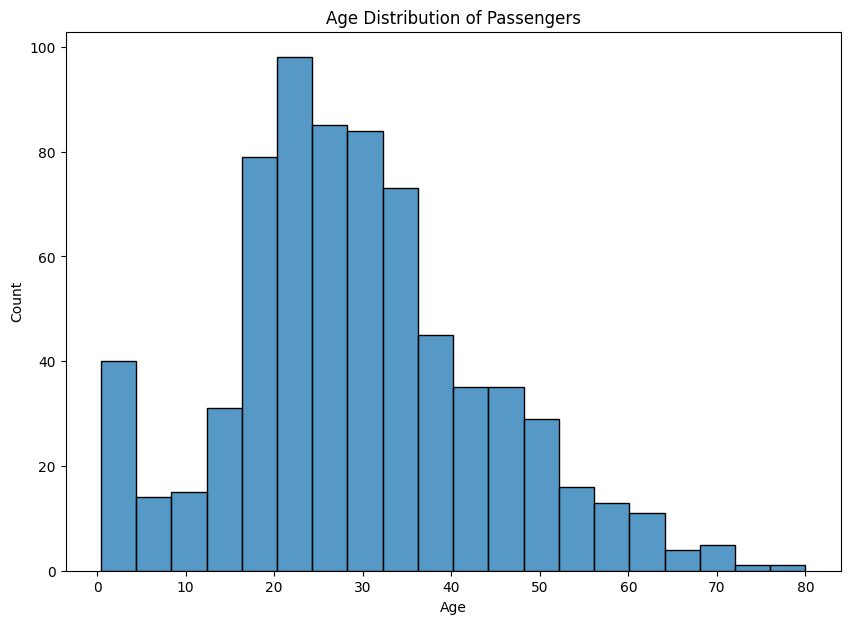

In [12]:
plt.figure(figsize=(10, 7))
sns.histplot(df['Age'], bins=20, kde=False)
plt.title('Age Distribution of Passengers')
plt.show()

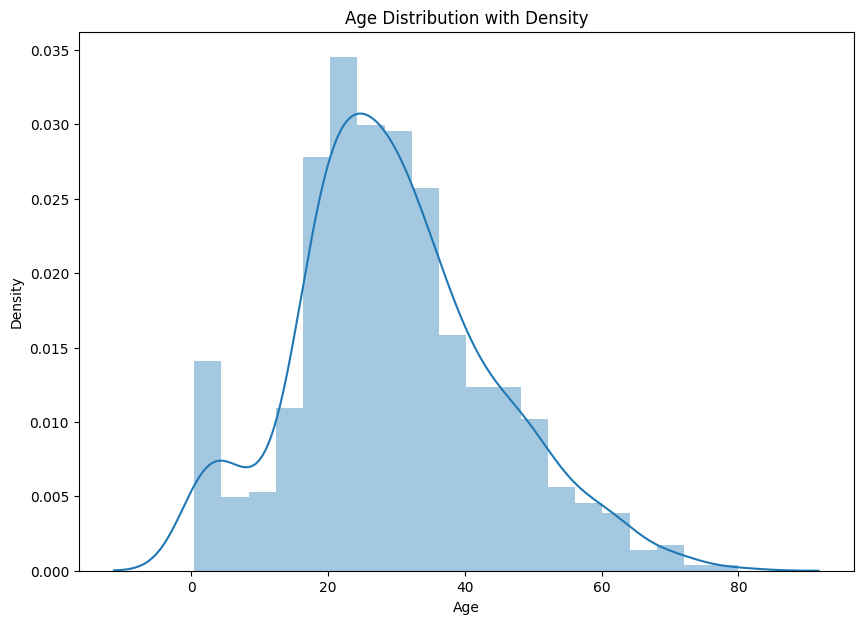

In [13]:
plt.figure(figsize=(10, 7))
sns.distplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution with Density')
plt.show()

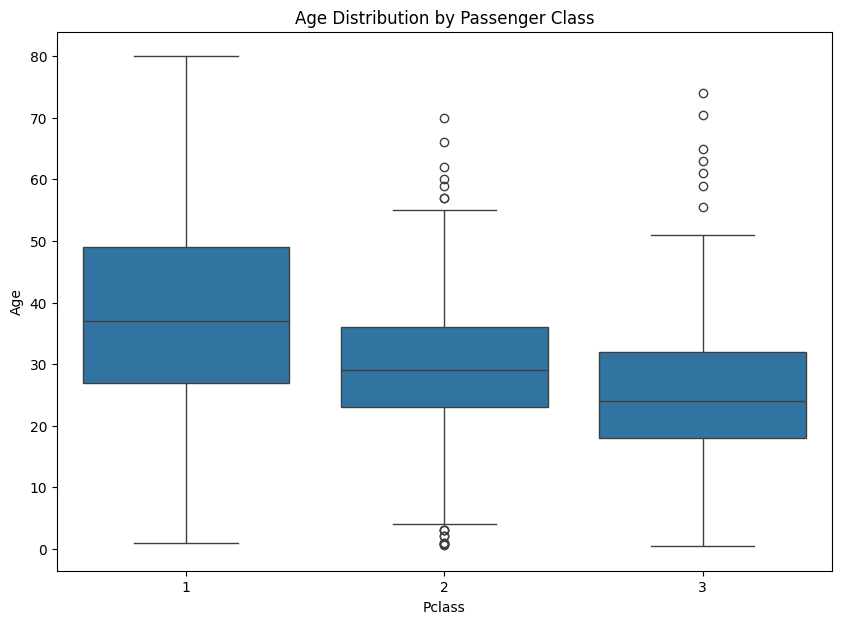

In [14]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Age Distribution by Passenger Class')
plt.show()

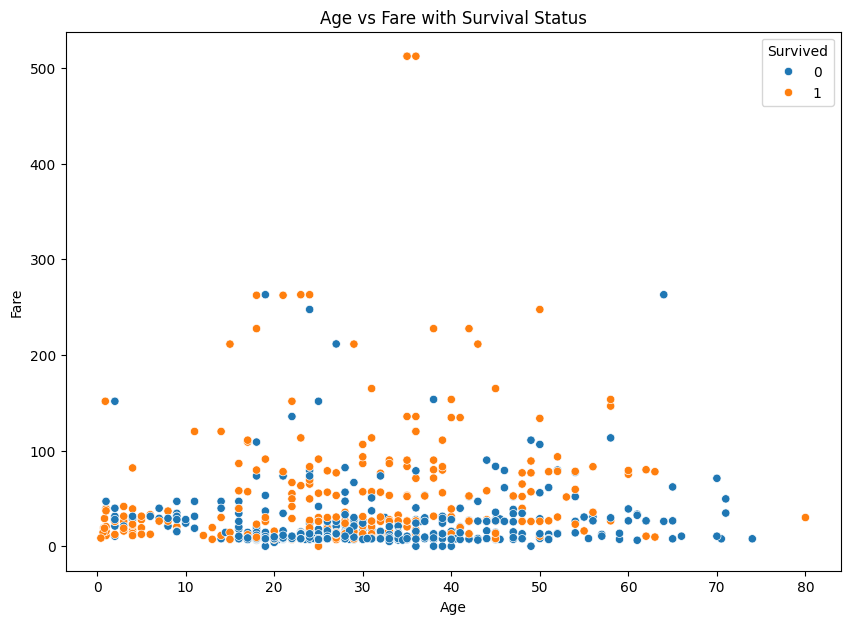

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived')
plt.title('Age vs Fare with Survival Status')
plt.show()

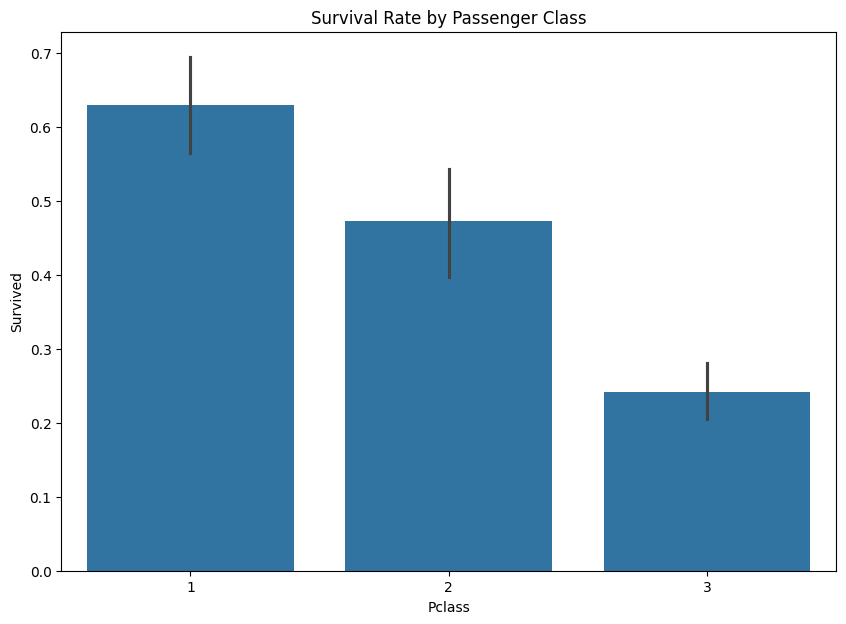

In [16]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

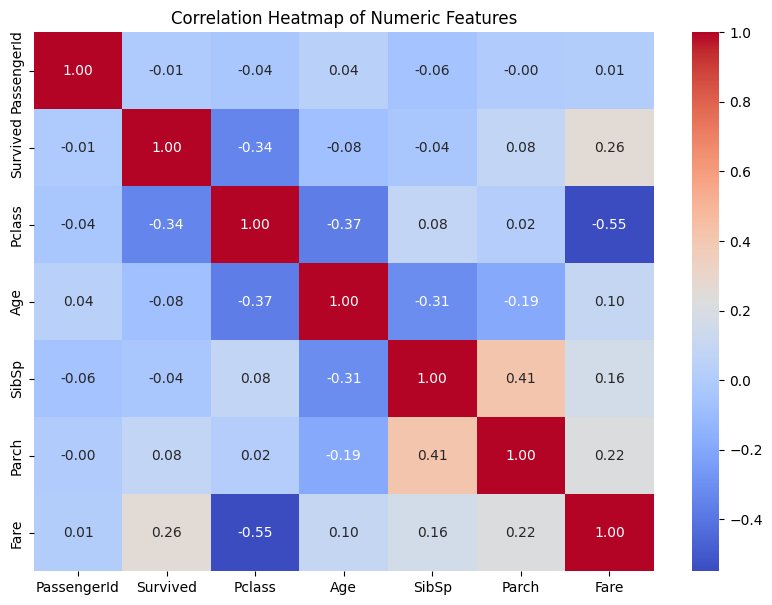

In [19]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
plt.figure(figsize=(10, 7))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

<Figure size 500x500 with 0 Axes>

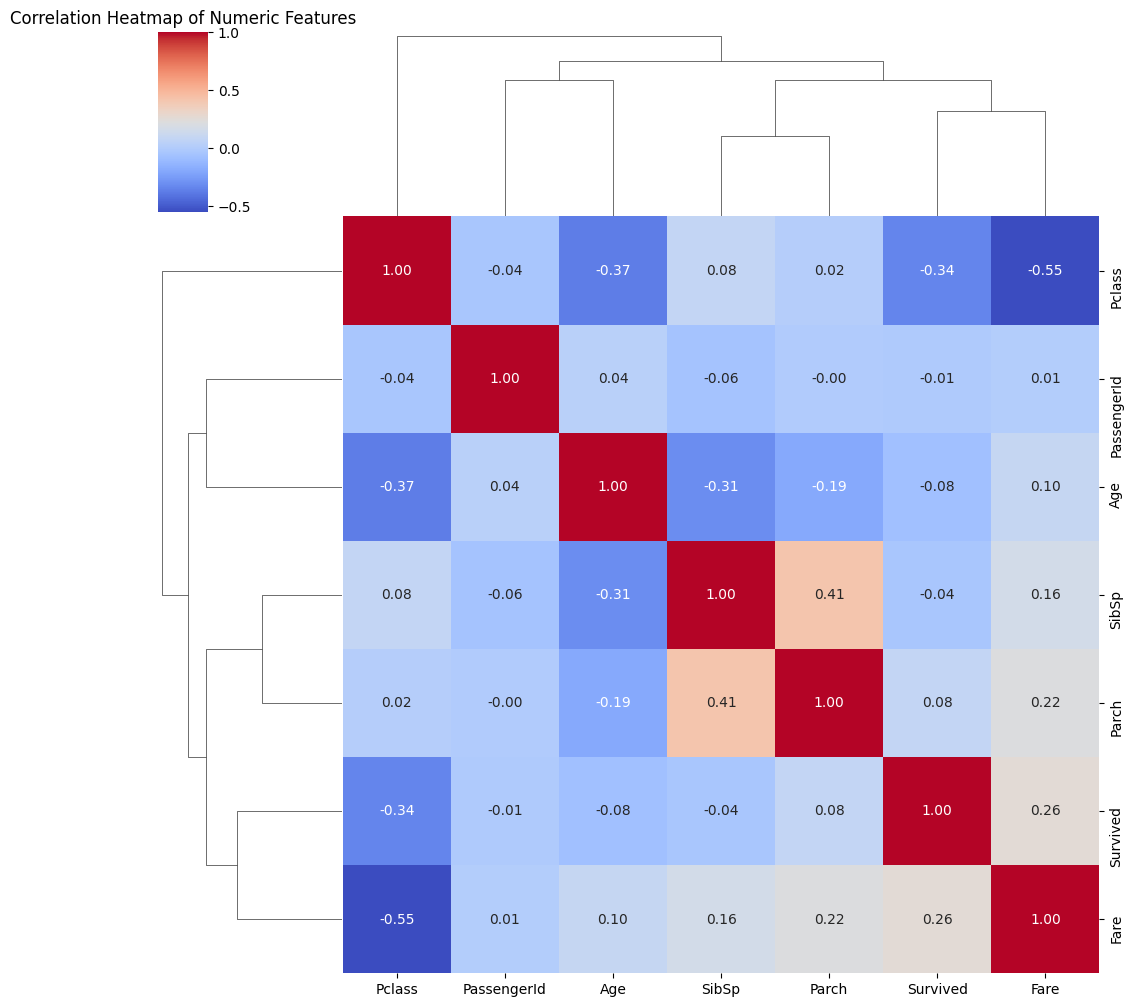

In [22]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
plt.figure(figsize=(5, 5))
corr = numeric_df.corr()
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()